# Checkpoint Two: Exploratory Data Analysis

Now that your chosen dataset is approved, it is time to start working on your analysis. Use this notebook to perform your EDA and make notes where directed to as you work.

## Getting Started

Since we have not provided your dataset for you, you will need to load the necessary files in this repository. Make sure to include a link back to the original dataset here as well.

My dataset: https://www.kaggle.com/datasets/arbelaezch/ncaam-basketball-game-schedules-2014-2024

Your first task in EDA is to import necessary libraries and create a dataframe(s). Make note in the form of code comments of what your thought process is as you work on this setup task.

In [33]:
# import necessary libraries with aliases
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# I have 10 different datasets to import, which will then be combined into 1 mega-dataframe, with an additional variable included to show which original dataframe the item came from.
df13_14 = pd.read_csv("../final-project-data/2013-14_schedule.csv")
df14_15 = pd.read_csv("../final-project-data/2014-15_schedule.csv")
df15_16 = pd.read_csv("../final-project-data/2015-16_schedule.csv")
df16_17 = pd.read_csv("../final-project-data/2016-17_schedule.csv")
df17_18 = pd.read_csv("../final-project-data/2017-18_schedule.csv")
df18_19 = pd.read_csv("../final-project-data/2018-19_schedule.csv")
df20_21 = pd.read_csv("../final-project-data/2020-21_schedule.csv")
df21_22 = pd.read_csv("../final-project-data/2021-22_schedule.csv")
df22_23 = pd.read_csv("../final-project-data/2022-23_schedule.csv")
df23_24 = pd.read_csv("../final-project-data/2023-24_schedule.csv")

# Adding a column for the relevant season
df13_14["Season"] = "2013-14"

# Checking to make sure that the column was entered properly.
df13_14.info()
df13_14.head()

# Adding the season column to all the other dataframes
df14_15["Season"] = "2014-15"
df15_16["Season"] = "2015-16"
df16_17["Season"] = "2016-17"
df17_18["Season"] = "2017-18"
df18_19["Season"] = "2018-19"
df20_21["Season"] = "2020-21"
df21_22["Season"] = "2021-22"
df22_23["Season"] = "2022-23"
df23_24["Season"] = "2023-24"

#making sure this worked on another dataframe
df23_24.head()

# It worked! I will now combine them all into one giant dataframe!
# Putting together a list of dataframes
dataframes_list = [df13_14, df14_15, df15_16, df16_17, df17_18, df18_19, df20_21, df21_22, df22_23, df23_24]
df = pd.concat(dataframes_list, ignore_index= True)

# I will now check the mega-dataframe
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11006 entries, 0 to 11005
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                11006 non-null  object 
 1   Type                11006 non-null  object 
 2   Team                11006 non-null  object 
 3   Conf.               11006 non-null  object 
 4   Opp.                11006 non-null  object 
 5   Venue               11006 non-null  object 
 6   Adj. O              11006 non-null  float64
 7   Adj. D              11006 non-null  float64
 8   T                   11006 non-null  float64
 9   O.EFF               11006 non-null  float64
 10  O.eFG%              11006 non-null  float64
 11  O.TO%               11006 non-null  float64
 12  O.Reb%              11006 non-null  float64
 13  O.FTR               11006 non-null  float64
 14  D.EFF               11006 non-null  float64
 15  D.eFG%              11006 non-null  float64
 16  D.TO

,Date,Type,Team,Conf.,Opp.,Venue,Adj. O,Adj. D,T,O.EFF,...,D.TO%,D.Reb%,D.FTR,G-Sc,+/-,Win,Points_For,Points_Against,Point_Differential,Season
0,2013-11-08,N,Duke,ACC,Davidson,Home,147.6,106.2,70.5,157.4,...,14.2,35.1,40.3,97.8,14,1,111,77,34,2013-14
1,2013-11-08,N,Wisconsin,B10,St. John's,Neutral,147.5,109.8,65.1,132.1,...,18.4,42.9,39.7,96.8,10,1,86,75,11,2013-14
2,2013-11-08,N,Saint Mary's,WCC,Louisiana Tech,Home,134.3,106.9,65.3,127.1,...,9.2,29.7,56.6,93.2,3,1,83,70,13,2013-14
3,2013-11-08,N,Fresno St.,MWC,UC Irvine,Away,129.4,119.4,73.9,117.9,...,18.1,36.4,40.8,71.5,-4,1,98,97,1,2013-14
4,2013-11-08,N,Connecticut,Amer,Maryland,Neutral,128.0,101.5,70.2,111.1,...,18.5,28.9,49.1,93.5,8,1,78,77,1,2013-14


## Get to Know the Numbers

Now that you have everything setup, put any code that you use to get to know the dataframe and its rows and columns better in the cell below. You can use whatever techniques you like, except for visualizations. You will put those in a separate section.

When working on your code, make sure to leave comments so that your mentors can understand your thought process.

In [ ]:
# Checking to see if there are any N/A values in columns 
df.isna().sum()

# No N/As!

In [32]:
# Before we look to describe the actual dataframe, I want to see if there are duplicates of events in each table. To do this, I'll check one of the smaller dataframes.
#'Duke' in df13_14["Team"]  and 'Davidson' in df13_14["Opp."]  or 'Davidson' in df13_14["Team"] and "Duke" in df13_14["Opp."]
team_a = 'Duke'
team_b = 'Davidson'
duke = df13_14['Team'] == team_a
davidson = df13_14['Team'] == team_b

filtered_rows = df13_14[duke]
filtered_rows2 = df13_14[davidson]
print(filtered_rows, filtered_rows2)

# It looks like each game *IS* in the dataframe twice... we will need to account for that when we are doing data cleaning. 

             Date Type  Team Conf.              Opp.    Venue  Adj. O  Adj. D  \
0      2013-11-08    N  Duke   ACC          Davidson     Home   147.6   106.2   
384    2013-11-12    N  Duke   ACC            Kansas  Neutral   124.6   106.0   
635    2013-11-15    N  Duke   ACC  Florida Atlantic     Home   129.4    93.0   
934    2013-11-18    N  Duke   ACC     UNC Asheville     Home   118.7    83.1   
1033   2013-11-19    N  Duke   ACC     East Carolina     Home   108.5    99.9   
1476   2013-11-24    N  Duke   ACC           Vermont     Home   148.6   134.3   
1807   2013-11-27    N  Duke   ACC           Alabama  Neutral   105.3    82.8   
1906   2013-11-29    N  Duke   ACC           Arizona  Neutral   119.3    94.4   
2277   2013-12-03    N  Duke   ACC          Michigan     Home   123.6    86.5   
3082   2013-12-16    N  Duke   ACC      Gardner Webb     Home   133.5   109.0   
3274   2013-12-19    N  Duke   ACC              UCLA  Neutral   115.8    80.1   
3709   2013-12-28    N  Duke

In [ ]:
# I will work to account for those rows at a later time. Now back to exploratory data analysis!
# Let's get some summary stats 
df.describe()
# We have to remember that we have duplicate rows, so that throws everything off... but honestly the only options we care about are Point_Differential (at least for our current question and purposes).

,Adj. O,Adj. D,T,O.EFF,O.eFG%,O.TO%,O.Reb%,O.FTR,D.EFF,D.eFG%,D.TO%,D.Reb%,D.FTR,G-Sc,Win,Points_For,Points_Against,Point_Differential
count,108110.000000,108110.000000,108110.000000,108110.000000,108110.000000,108110.000000,108110.000000,108110.000000,108110.000000,108110.000000,108110.000000,108110.000000,108110.000000,108110.000000,108110.000000,108110.000000,108110.000000,108110.000000
mean,103.839220,103.095438,68.192722,103.379821,50.356156,18.300381,28.943264,35.109465,103.379821,50.356156,18.300381,28.943264,35.109465,50.931547,0.500000,77.084488,65.197725,11.886763
std,13.982832,13.478265,5.671272,15.303539,8.656261,5.445724,9.228174,15.689865,15.303539,8.656261,5.445724,9.228174,15.689865,31.640339,0.500002,10.798666,10.745424,9.153406
min,47.000000,46.100000,46.700000,34.900000,12.200000,0.000000,0.000000,0.000000,34.900000,12.200000,0.000000,0.000000,0.000000,0.000000,0.000000,38.000000,24.000000,1.000000
25%,94.400000,94.000000,64.300000,93.200000,44.400000,14.500000,22.600000,23.800000,93.200000,44.400000,14.500000,22.600000,23.800000,21.400000,0.000000,70.000000,58.000000,5.000000
50%,103.600000,103.000000,68.000000,103.500000,50.000000,18.000000,28.600000,33.300000,103.500000,50.000000,18.000000,28.600000,33.300000,51.200000,0.500000,77.000000,65.000000,10.000000
75%,113.000000,112.100000,71.800000,113.600000,56.100000,21.800000,35.100000,44.100000,113.600000,56.100000,21.800000,35.100000,44.100000,80.700000,1.000000,84.000000,72.000000,16.000000
max,167.200000,166.100000,97.700000,174.200000,91.700000,49.600000,69.100000,184.800000,174.200000,91.700000,49.600000,69.100000,184.800000,100.000000,1.000000,149.000000,144.000000,80.000000


In [ ]:
# Listing all the columns
df.columns
# The columns that we care about are: Date, Type, Team, Conf., Opp. Venue, Points_For, Points_Against, Point_Differential, and Season

Index(['Date', 'Type', 'Team', 'Conf.', 'Opp.', 'Venue', 'Adj. O', 'Adj. D',
       'T', 'O.EFF', 'O.eFG%', 'O.TO%', 'O.Reb%', 'O.FTR', 'D.EFF', 'D.eFG%',
       'D.TO%', 'D.Reb%', 'D.FTR', 'G-Sc', '+/-', 'Win', 'Points_For',
       'Points_Against', 'Point_Differential', 'Season'],
      dtype='object')

In [39]:
# Let's look at the conference breakdown
df['Conf.'].value_counts()

Conf.
ACC     4975
SEC     4650
B10     4615
A10     4425
CUSA    4087
P12     3954
MAC     3631
Amer    3611
SB      3560
B12     3502
BE      3424
MWC     3422
MAAC    3402
OVC     3388
Slnd    3356
BSky    3278
MVC     3249
CAA     3191
MEAC    3176
Horz    3145
SWAC    3143
BSth    3108
WCC     3056
SC      3001
Pat     2961
NEC     2887
ASun    2848
BW      2842
WAC     2785
AE      2684
Sum     2610
Ivy     2009
ind      106
Ind       29
Name: count, dtype: int64

It looks like we have a couple of conference values that should be combined -- mainly 'ind' and 'Ind'. These both stand for independent schools.

In [ ]:
# Checking the different value counts for Type
df['Type'].value_counts()

Type
C     61654
N     38000
CT     5848
T      1338
P      1270
Name: count, dtype: int64

It looks like there are `61654/2` conference games, `19,000` non-conference games, `5,848/2` conference tournament games, `1338/2` NCAA tournament games, and `1270/2` NIT games. The NIT and NCAA Tournament games may count as non-conference games, it depends on the two teams playing.

In [ ]:
df['Win'].value_counts()


Win
1    54055
0    54055
Name: count, dtype: int64

In [71]:
# Looking at non-conference wins over the entire dataset, differentiated by season, sorted below.
filter_values = ['N','T','P']
df_temp = df[df['Type'].isin(filter_values)]
nc_wins = df_temp.groupby(['Conf.','Season'])['Win'].sum().sort_values(ascending=False)
print(nc_wins)

Conf.  Season 
ACC    2016-17    169
       2015-16    168
       2014-15    167
       2018-19    167
       2017-18    165
                 ... 
BSky   2020-21      9
SWAC   2020-21      8
ind    2022-23      7
NEC    2020-21      6
Pat    2020-21      6
Name: Win, Length: 323, dtype: int64


## Visualize

Create any visualizations for your EDA here. Make note in the form of code comments of what your thought process is for your visualizations.

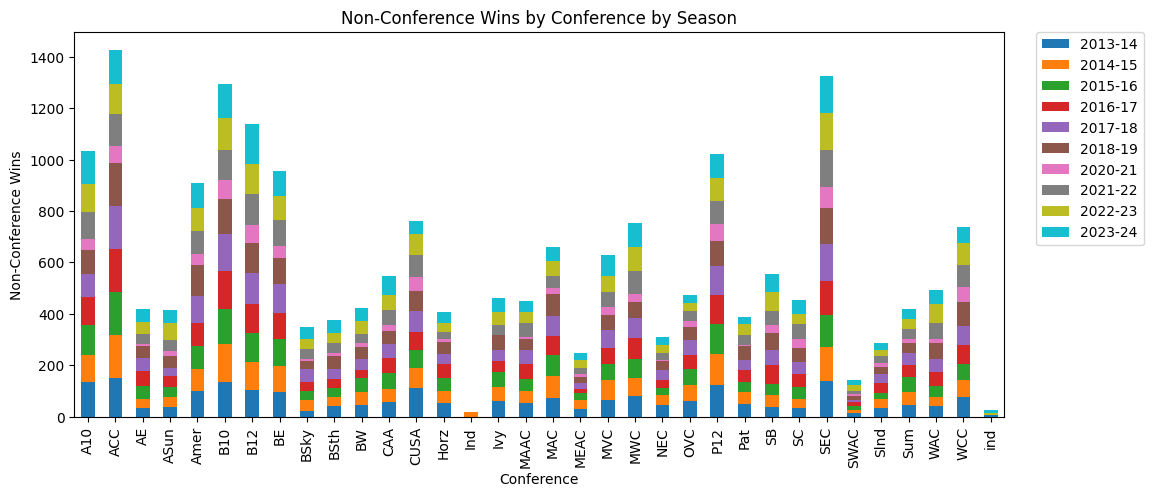

In [92]:
# Creating a bar plot showing non-conference wins by season.


nc_wins = nc_wins.unstack()
nc_wins.plot(kind='bar', stacked=True, figsize= (12,5))

plt.title('Non-Conference Wins by Conference by Season')
plt.legend(bbox_to_anchor = (1.15,1), loc = 'upper right', borderaxespad = 0.)
plt.xlabel('Conference')
plt.ylabel('Non-Conference Wins')
plt.show()

## Summarize Your Results

With your EDA complete, answer the following questions.

1. Was there anything surprising about your dataset? 
    The most surprising aspect of my dataset is that each game is in the system twice!
2. Do you have any concerns about your dataset? 
    The biggest concern I have about the dataset is that each game is in the dataset twice, and not only that but the conference only shows for the "Team", not the opponent. This will be something I need to address in the next phase of analysis/data cleanup.
3. Is there anything you want to make note of for the next phase of your analysis, which is cleaning data? 
    To reiterate, the largest concern I have is how to adjust the dataset to account for each game being in there twice, and the conference not showing for both teams in each row.